In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("students.csv")

In [3]:
df.head()

,student_id,name,age,gender,city,study_hours,attendance_pct,sleep_hours,score
0,STU089,Anish Sharma,16,M,Butwal,4.1,100%,8.4,100.0
1,STU126,Anish Shrestha,17,M,Biratnagar,5.8,82.0,6.0,100.0
2,STU046,Manisha Thapa,15,female,Kathmandu,2.7,63.0,7.4,68.0
3,STU012,Sunita Adhikari,18,F,Biratnagar,5.1,NaN,7.2,87.0
4,STU053,Rina Karki,18,F,Pokhara,0.5,67%,8.0,70.0


In [4]:
df.tail()

,student_id,name,age,gender,city,study_hours,attendance_pct,sleep_hours,score
147,STU143,Rina Adhikari,18,F,Biratnagar,2.6,86.0,4.1,89.0
148,STU093,Nabin Gurung,15,M,Kathmandu,4.7,90%,6.4,100.0
149,STU104,Kriti Gurung,15,Female,Butwal,4.6,80.0,5.9,100.0
150,STU068,Nabin Thapa,15,Male,Lalitpur,4.9,85.0,6.2,100.0
151,STU026,Kiran Sharma,15,MALE,Butwal,5.3,86.0,4.5,100.0


In [5]:
df.shape

(152, 9)

In [6]:
df.columns

Index(['student_id', 'name', 'age', 'gender', 'city', 'study_hours',
       'attendance_pct', 'sleep_hours', 'score'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      152 non-null    object 
 1   name            152 non-null    object 
 2   age             152 non-null    int64  
 3   gender          152 non-null    object 
 4   city            152 non-null    object 
 5   study_hours     152 non-null    float64
 6   attendance_pct  137 non-null    object 
 7   sleep_hours     146 non-null    float64
 8   score           145 non-null    float64
dtypes: float64(3), int64(1), object(5)
memory usage: 10.8+ KB


In [8]:
df.describe()

,age,study_hours,sleep_hours,score
count,152.000000,152.000000,146.000000,145.000000
mean,16.809211,4.445395,6.783562,97.889655
std,10.967582,1.862166,1.119238,76.602248
min,14.000000,-2.000000,3.500000,0.000000
25%,15.000000,3.275000,6.000000,86.000000
50%,16.000000,4.650000,6.750000,100.000000
75%,17.000000,5.825000,7.475000,100.000000
max,150.000000,8.700000,9.700000,1000.000000


In [9]:
df['gender'].unique()

array(['M', 'female', 'F', 'male', 'MALE', 'Female', 'Female ', 'Male'],
      dtype=object)

In [10]:
# Mapping
df['gender'] = df['gender'].str.strip()

gender_mapping = {
    'M': 'Male',
    'male' : 'Male',
    'MALE' : 'Male',
    'Male' : 'Male',
    'female' : 'Female',
    'Female' : 'Female',
    'Female ' : 'Female',
    'F': 'Female'
}

df['gender'] = df['gender'].map(gender_mapping)

In [11]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

<Axes: xlabel='gender'>

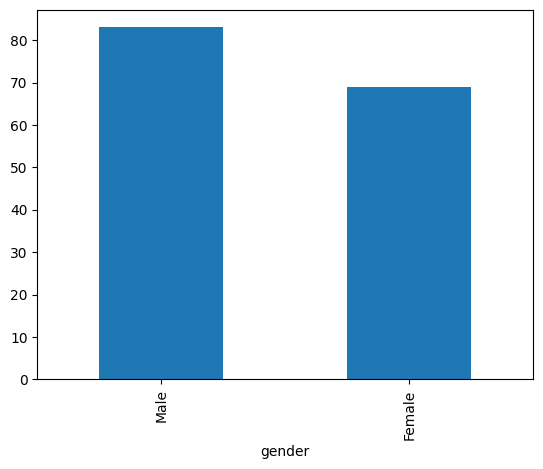

In [12]:
df["gender"].value_counts().plot(kind='bar')

<Axes: xlabel='gender', ylabel='count'>

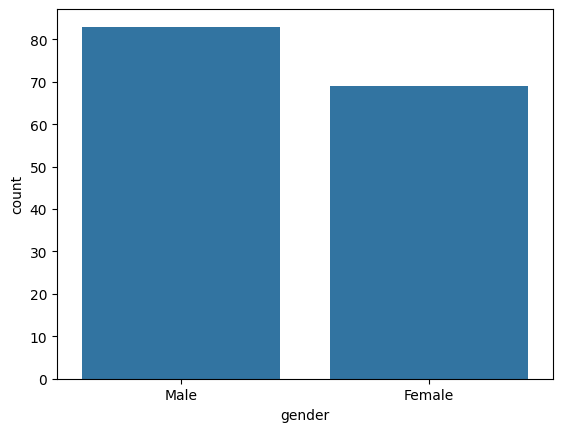

In [13]:
sns.countplot(data=df, x = 'gender')

In [14]:
# Missing Values
df.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
city,0
study_hours,0
attendance_pct,15
sleep_hours,6
score,7


In [21]:
df['attendance_pct'] = df['attendance_pct'].str.replace('%', '', regex=False)

In [22]:
df['attendance_pct'] = pd.to_numeric(df['attendance_pct'], errors='coerce')

In [23]:
df.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
city,0
study_hours,0
attendance_pct,15
sleep_hours,6
score,7


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      152 non-null    object 
 1   name            152 non-null    object 
 2   age             152 non-null    int64  
 3   gender          152 non-null    object 
 4   city            152 non-null    object 
 5   study_hours     152 non-null    float64
 6   attendance_pct  137 non-null    float64
 7   sleep_hours     146 non-null    float64
 8   score           145 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 10.8+ KB


In [25]:
df['attendance_pct'] = df['attendance_pct'].fillna(df.groupby('gender')['attendance_pct'].transform('median'))

In [26]:
df.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
city,0
study_hours,0
attendance_pct,0
sleep_hours,6
score,7


In [30]:
corr = df[['age', 'attendance_pct','sleep_hours', 'score', 'study_hours']].corr()

<Axes: >

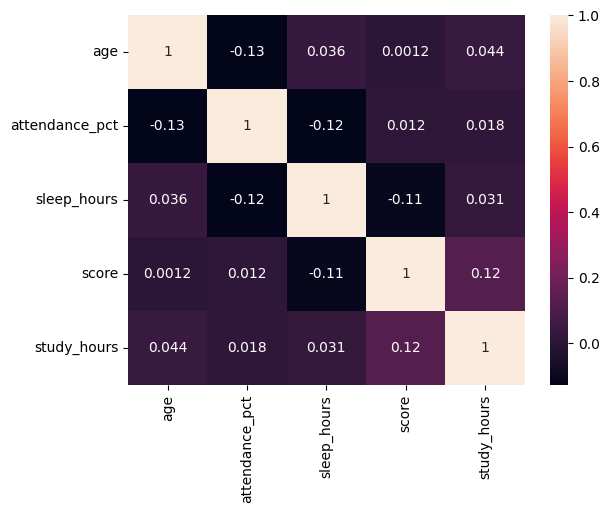

In [31]:
sns.heatmap(corr , annot=True)

<Axes: xlabel='attendance_pct', ylabel='Count'>

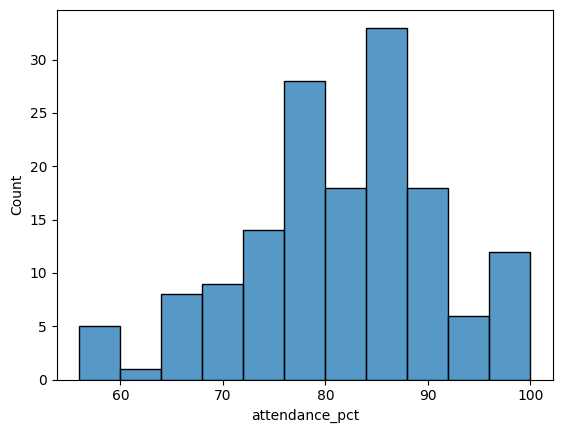

In [34]:
sns.histplot(data = df, x='attendance_pct')

In [35]:
df['attendance_pct_log'] = np.log(df['attendance_pct'])

<Axes: xlabel='attendance_pct_log', ylabel='Count'>

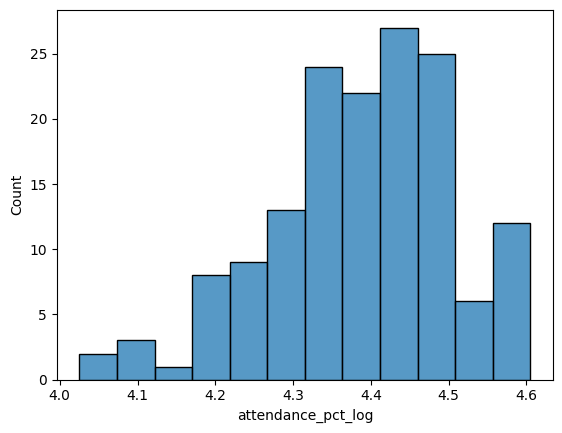

In [36]:
sns.histplot(data = df, x='attendance_pct_log')

In [37]:
df['attendance_pct'].skew()

np.float64(-0.20860685248545813)

In [38]:
df['attendance_pct_log'].skew()

np.float64(-0.5570767613676946)

<Axes: xlabel='score'>

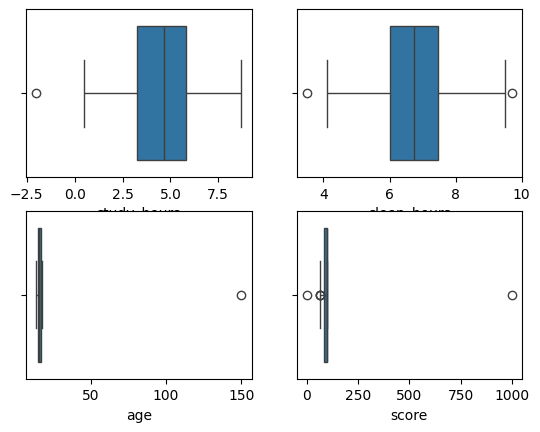

In [39]:
plt.subplot(2,2,1)
sns.boxplot(data=df, x='study_hours')
plt.subplot(2,2,2)
sns.boxplot(data=df, x='sleep_hours')
plt.subplot(2,2,3)
sns.boxplot(data=df, x='age')
plt.subplot(2,2,4)
sns.boxplot(data=df, x='score')

In [40]:
df = df[df['age']<= 100]

In [41]:
df = df[df['study_hours']>= 0]

In [42]:
df = df[df['score'] <= 100]

<Axes: xlabel='score'>

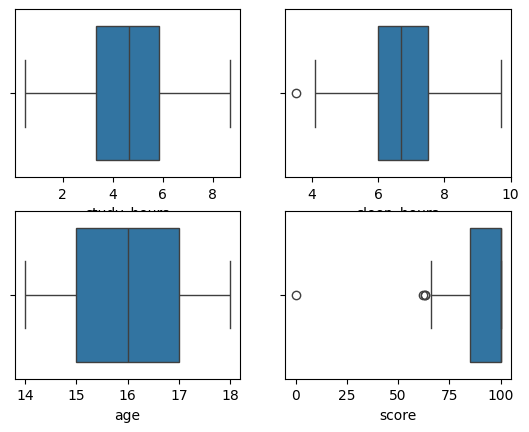

In [43]:
plt.subplot(2,2,1)
sns.boxplot(data=df, x='study_hours')
plt.subplot(2,2,2)
sns.boxplot(data=df, x='sleep_hours')
plt.subplot(2,2,3)
sns.boxplot(data=df, x='age')
plt.subplot(2,2,4)
sns.boxplot(data=df, x='score')

In [45]:
df.shape

(142, 10)

In [47]:
numerical_cols = ['study_hours', 'age', 'sleep_hours', 'score']

for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[col] = df[col].clip(lower_bound,upper_bound)

<Axes: xlabel='score'>

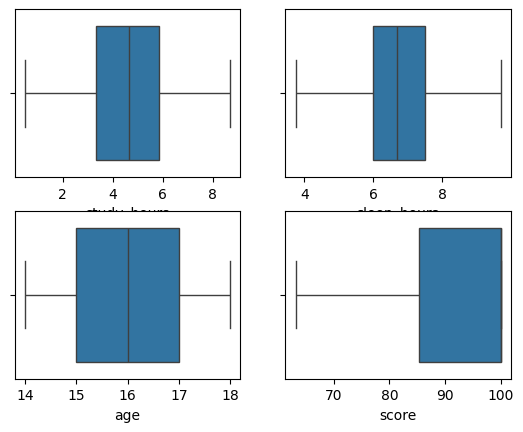

In [48]:
plt.subplot(2,2,1)
sns.boxplot(data=df, x='study_hours')
plt.subplot(2,2,2)
sns.boxplot(data=df, x='sleep_hours')
plt.subplot(2,2,3)
sns.boxplot(data=df, x='age')
plt.subplot(2,2,4)
sns.boxplot(data=df, x='score')

In [51]:
df.shape

(142, 8)

In [49]:
df.drop(columns = ['student_id', 'name'], axis = 1,inplace = True)

In [50]:
df.head()

,age,gender,city,study_hours,attendance_pct,sleep_hours,score,attendance_pct_log
0,16,M,Butwal,4.1,100.0,8.4,100.0,4.605170
1,17,M,Biratnagar,5.8,82.0,6.0,100.0,4.406719
2,15,female,Kathmandu,2.7,63.0,7.4,68.0,4.143135
3,18,F,Biratnagar,5.1,85.0,7.2,87.0,4.442651
4,18,F,Pokhara,0.5,67.0,8.0,70.0,4.204693


In [52]:
df['eff'] = df['study_hours'] * df['attendance_pct']

In [53]:
df.head()

,age,gender,city,study_hours,attendance_pct,sleep_hours,score,attendance_pct_log,eff
0,16,M,Butwal,4.1,100.0,8.4,100.0,4.605170,410.0
1,17,M,Biratnagar,5.8,82.0,6.0,100.0,4.406719,475.6
2,15,female,Kathmandu,2.7,63.0,7.4,68.0,4.143135,170.1
3,18,F,Biratnagar,5.1,85.0,7.2,87.0,4.442651,433.5
4,18,F,Pokhara,0.5,67.0,8.0,70.0,4.204693,33.5
